# 07 Parallel runs: tiles on several devices

- **Tier:** cluster (one CPU node; the run below used 8 cores)
- **Run time:** about 28 min (measured: 1645 s on a compute node pinned to 8 cores: each forward run about 3 min,
  each gradient 3.5 min, mostly compiling)
- **Peak memory:** about 6 GB (measured: 5.5 GiB)
- **Experiment:** `verification/tutorial_global_oce_optim`, variant `input_ad` (global 90 x 40 x 15 ocean in four
  tiles of 45 x 20, 10 steps; cost and control `xx_qnet` of `data.ctrl`)
- **Shows:** the forward run split over 2, 3 and 4 devices gives the single-device result bit for bit; the
  gradient split over devices agrees with the single-device gradient to about 1e-14; why it is not bitwise, how
  global sums are kept in a fixed order, and how GPUs are used.

MITgcm splits its domain into tiles (`SIZE.h`: `sNx`, `sNy`, `nSx`, `nSy`) and gives tiles to MPI processes
(`nPx`, `nPy`). mitjax keeps all tiles in one array, `[tile, k, j, i]`, and gives blocks of tiles to JAX devices:
the same code runs on one device or on several (`jax.shard_map`), and the halo exchange between tiles on
different devices becomes a device-to-device copy (`jax.lax.ppermute`). Nothing in `SIZE.h` changes: the tiling is
the experiment's, the number of devices is a run-time choice.

Both go through the API: `exp.run(out, devices=N)` for the forward run and `exp.gradient(out, devices=N)` for the
gradient.

In [1]:
import os
os.environ.setdefault("JAX_PLATFORMS", "cpu")
from mitjax.xla_flags import set_api_xla_flags
set_api_xla_flags()                                # before JAX starts: 4 CPU devices (and the API's other flags)

import time
from pathlib import Path

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

import mitjax
from mitjax import paths

VERIFICATION = paths.UPSTREAM / "verification"
print("XLA_FLAGS:", os.environ["XLA_FLAGS"])
print("JAX devices:", jax.devices())


def new_out(name):
    """A new output directory runs/<name>-<n> next to this notebook (mitjax never writes into an existing one)."""
    n = 1
    while Path(f"runs/{name}-{n}").exists():
        n += 1
    return Path(f"runs/{name}-{n}")


def bits_differ(a, b):
    """Number of values whose bit patterns differ between two dicts of arrays with the same names and shapes."""
    assert sorted(a) == sorted(b)
    n = 0
    for k in a:
        x, y = np.ascontiguousarray(a[k], np.float64), np.ascontiguousarray(b[k], np.float64)
        n += int(np.count_nonzero(x.view(np.int64) != y.view(np.int64)))
    return n

XLA_FLAGS: --xla_cpu_max_isa=AVX --xla_disable_hlo_passes=algsimp --xla_force_host_platform_device_count=4


JAX devices: [CpuDevice(id=0), CpuDevice(id=1), CpuDevice(id=2), CpuDevice(id=3)]


On a CPU, JAX can pretend to have several devices: the XLA flag `--xla_force_host_platform_device_count=4`
(set by `set_api_xla_flags()`, which every API call also runs; it must run before JAX starts to take effect, and
a value you set yourself in `XLA_FLAGS` wins) splits the machine into four "devices". They share the cores, so this is not faster than one device; it runs the same
parallel program that several GPUs or nodes would run, which is what we want to check here.

## 1. The forward run on 1 to 4 devices

`exp.run(out, devices=P)` runs the time loop with the tiles split over P devices: each device gets a block of
tiles, and the halo exchange sends the edges between devices. We run the 10 steps on one device and on 2, 3 and 4,
and compare the final state (`run.fields`, every field of every tile) and the `output.txt` each run writes.

In [2]:
exp = mitjax.load(VERIFICATION / "tutorial_global_oce_optim", variant="input_ad")
sz = exp.config.cfg.size
print(f"{sz.Nx} x {sz.Ny} x {sz.Nr} in {sz.nSx * sz.nSy} tiles of {sz.sNx} x {sz.sNy}")

FORWARD_DEVICES = (1, 2, 3, 4)                     # 3: two tiles per device, two padding tiles
runs = {}
for P in FORWARD_DEVICES:
    t0 = time.time()
    runs[P] = exp.run(out=new_out(f"07_forward_p{P}"), devices=P)
    print(f"devices={P}: {time.time() - t0:.0f} s")
    jax.clear_caches()

forward_bits, same_output = {}, {}
n_values = sum(np.size(a) for a in runs[1].fields.values())
for P in FORWARD_DEVICES[1:]:
    forward_bits[P] = bits_differ(runs[P].fields, runs[1].fields)
    same_output[P] = runs[P].output.read_text() == runs[1].output.read_text()
    print(f"devices={P}: values that differ from devices=1: {forward_bits[P]} of {n_values}; "
          f"output.txt identical: {same_output[P]}")

90 x 40 x 15 in 4 tiles of 45 x 20


devices=1: 160 s


devices=2: 200 s


devices=3: 200 s


devices=4: 200 s


devices=2: values that differ from devices=1: 0 of 1307712; output.txt identical: True
devices=3: values that differ from devices=1: 0 of 1307712; output.txt identical: True
devices=4: values that differ from devices=1: 0 of 1307712; output.txt identical: True


Every value of the final state (all fields, all tiles) is identical at P = 1, 2, 3 and 4, and so is every line of
`output.txt` (the monitor statistics and the solver's residuals). This is a statement about
one machine and one XLA build: the same program, split differently, does the same arithmetic in the same order.
On another CPU the P = 1 result itself may round differently from ours; we expect P = N to equal P = 1 there
too, but we have not tested it.

In [3]:
FORWARD_BITS_EXPECTED = 0                          # bitwise: no value differs
assert all(n == FORWARD_BITS_EXPECTED for n in forward_bits.values()), forward_bits
assert all(same_output.values()), same_output

## 2. The gradient on 1 to 4 devices (the API)

`exp.gradient(devices=N)` runs the adjoint of the experiment's cost with respect to its control, split over N
devices: JAX differentiates the sharded program, so the reverse sweep is sharded too (the transpose of a
device-to-device copy is the copy back).

In [4]:
GRADIENT_DEVICES = (1, 2, 3, 4)
grads = {}
for P in GRADIENT_DEVICES:
    t0 = time.time()
    grads[P] = exp.gradient(out=new_out(f"07_gradient_p{P}"), devices=P)
    print(f"devices={P}: {time.time() - t0:.0f} s, fc = {grads[P].fc:.15E}")
    jax.clear_caches()

g1 = grads[1].adxx[1]
rel = {}
for P in GRADIENT_DEVICES[1:]:
    gP = grads[P].adxx[1]
    rel[P] = float(np.max(np.abs(gP - g1)) / np.max(np.abs(g1)))
    print(f"devices={P}: fc identical: {grads[P].fc == grads[1].fc}; max|g_P - g_1| / max|g_1| = {rel[P]:.1E}; "
          f"{np.count_nonzero(gP != g1)} of {g1.size} values differ")

devices=1: 201 s, fc = 6.200232281823371E+00


devices=2: 221 s, fc = 6.200232281823371E+00


devices=3: 223 s, fc = 6.200232281823371E+00


devices=4: 221 s, fc = 6.200232281823371E+00
devices=2: fc identical: True; max|g_P - g_1| / max|g_1| = 1.3E-14; 627 of 4704 values differ
devices=3: fc identical: True; max|g_P - g_1| / max|g_1| = 1.3E-14; 627 of 4704 values differ
devices=4: fc identical: True; max|g_P - g_1| / max|g_1| = 7.1E-15; 435 of 4704 values differ


Which values of `devices` work? Here every value from 1 to the number of JAX devices (4): the tiles are dealt
out in equal blocks, and when the number of devices does not divide the number of tiles (3 here), the blocks are
padded with dummy tiles that compute finite values and are dropped. More devices than JAX has is an error,
`DeviceCountError` (a `ValueError`, and also a `RuntimeError`), raised before anything is written:

In [5]:
from mitjax.api import DeviceCountError

too_many = new_out("07_gradient_too_many")
try:
    exp.gradient(out=too_many, devices=len(jax.devices()) + 1)
except DeviceCountError as e:
    err = e
    print(f"{type(err).__name__}: {err}")
else:
    raise AssertionError("devices > len(jax.devices()) must fail")
assert isinstance(err, ValueError) and isinstance(err, RuntimeError)
assert not too_many.exists()                       # refused before the run directory is made

DeviceCountError: devices=5: JAX has 4 device(s) (cpu); on CPU, XLA_FLAGS=--xla_force_host_platform_device_count=N set before JAX starts gives N


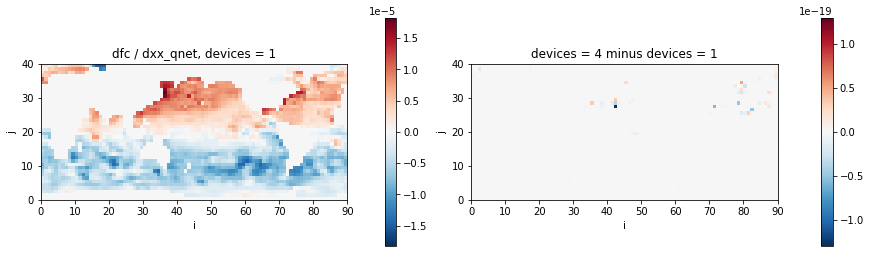

In [6]:
tiles = runs[1].tilemap                            # how the tiles make up the global field (Run.global_field)
Plast = GRADIENT_DEVICES[-1]
g = tiles.global_field(g1)                         # [tile, j, i] with halos -> [j, i]
d = tiles.global_field(grads[Plast].adxx[1]) - g
fig, ax = plt.subplots(1, 2, figsize=(12, 3.4), dpi=72, constrained_layout=True)
pc = ax[0].pcolormesh(g, cmap="RdBu_r", vmin=-abs(g).max(), vmax=abs(g).max())
fig.colorbar(pc, ax=ax[0])
ax[0].set_title("dfc / dxx_qnet, devices = 1")
pc = ax[1].pcolormesh(d, cmap="RdBu_r", vmin=-abs(d).max() or 1, vmax=abs(d).max() or 1)
fig.colorbar(pc, ax=ax[1])
ax[1].set_title(f"devices = {Plast} minus devices = 1")
for a in ax:
    a.set_xlabel("i"); a.set_ylabel("j"); a.set_aspect("equal")
plt.show()

**Why the gradient is not bitwise.** The forward is the same arithmetic in the same order at any P. In the
reverse sweep, the transpose of a halo exchange adds the sensitivities of a point's halo copies back onto the
point. On one device those additions happen in one order; where a tile edge is also a device edge, the copies
arrive in another order, so the sum differs in the last bit at some points, and the reverse sweep carries these
differences on. What matters is which tile edges are device edges, not P itself: devices = 2 and devices = 3 split
the four tiles at the same place (tiles 1-2 | 3-4, plus padding at P = 3) and give the same gradient bit for bit.

**Our bar.** Our tests require max|g_P - g_1| <= 1e-14 max|g_1| (the "R5" bar of our test suite). Here devices = 4
meets it (7.1e-15). At devices = 2 and 3 the gradient differs by 1.32e-14 (the two are bit for bit equal: the same
device edges). That is above 1e-14, so our rule for such windows (plan decision 18, below) judges them against
this window's own rounding floor. The floor is measured on one device by perturbing the adjoint state by one unit
in the last place (relative, a fixed +-1 pattern) at each step boundary of the same 10-step window: it is
2.0e-14. One last-bit change anywhere in the reverse sweep moves this gradient by up to 2.0e-14, more than the
sharding does. Devices = 2 and 3 sit at 0.66 x the floor, well inside the bar of 10 x floor = 2.0e-13 (our test
suite asserts it in `mitjax/tests/test_r5_sharded_grad_cpu.py`; the floor is not remeasured here).

In [7]:
R5_BAR = 1e-14                                     # max|g_P - g_1| <= 1e-14 max|g_1|
for P in GRADIENT_DEVICES[1:]:
    assert grads[P].fc == grads[1].fc              # the cost: global sums in tile order (section 3)
    assert np.isfinite(grads[P].adxx[1]).all()
assert rel[4] <= R5_BAR, rel
FLOOR, C = 2.007e-14, 10                           # decision 18: this window's measured one-ulp floor, factor C
assert all(rel[P] <= C * FLOOR for P in (2, 3)), rel
assert np.array_equal(grads[2].adxx[1], grads[3].adxx[1])     # the same device edges: the same gradient

**Longer windows.** The reverse sweep can amplify last-bit differences. For `global_ocean.cs32x15/input_ad`
(cubed sphere, 12 tiles, 5 steps) we measured on fake CPU devices max|g_P - g_1| / max|g_1| = 6.0e-14 (P = 6),
1.8e-13 (P = 5) and 2.2e-13 (P = 2), with every solver iteration count identical at all P. The cause is the
gradient's own sensitivity to rounding, not the sharding: changing one value of the reverse sweep by one unit in
the last place, on one device, moves this gradient by as much (up to 2.3e-13). So for windows that do not meet
1e-14 our tests use the measured floor, as above: max|g_P - g_1| <= 10 x floor, where the floor is the largest change
of the P = 1 gradient caused by one-ulp perturbations of the adjoint state at each step boundary of the same
window (2.3e-13 for this one). These numbers come from our test suite
(`mitjax/tests/test_m4costshard_grad_cpu.py`); this notebook does not rerun them (each cubed-sphere adjoint
program takes about 15 minutes to compile).

## 3. Global sums in a fixed order

A global sum (the cost function, the conjugate-gradient solver's dot products, the monitor statistics) adds
numbers from all tiles. Floating-point addition is not associative, so the order matters in the last bit. MITgcm
fixes it in two stages: each tile's partial sum in the caller's `DO j; DO i` loop order, then
`GLOBAL_SUM_TILE_RL` adds the partials in tile order 1, 2, ... (with MPI too: the partials of all processes are
collected first). mitjax does the same (`mitjax/eesupp/global_sum.py`); on several devices the partials are
gathered to every device (a sum of zero-padded vectors, which is exact) and then added in tile order. So the order
of additions does not depend on P, and the forward values, the cost and the solvers' iteration counts are the
same on any number of devices. A plain `jnp.sum` would not do: XLA adds in a tree whose shape it chooses.

In [8]:
from mitjax.eesupp.global_sum import global_sum_rl

x = jnp.asarray(np.random.default_rng(2).standard_normal((4, 20, 45)))     # [tile, j, i]
in_order = float(global_sum_rl(x))                 # per tile j outer, i inner; then tile 1 + 2 + 3 + 4
reversed_tiles = float(global_sum_rl(x[::-1]))     # the same numbers, tiles in the opposite order
tree = float(jnp.sum(x))                           # XLA's reduction tree
print(f"tile order       {in_order!r}\nreversed tiles   {reversed_tiles!r}\njnp.sum          {tree!r}")
print(f"differences: {in_order - reversed_tiles:.1E}, {in_order - tree:.1E}")

tile order       -43.957233991824964
reversed tiles   -43.95723399182497
jnp.sum          -43.957233991825
differences: 7.1E-15, 3.6E-14


## 4. GPUs

On GPUs nothing in the code changes: each device is a GPU and the halo copies go from GPU to GPU. Our test suite
runs the same sharded gradient programs on 1 and 4 A100 GPUs. Two things differ from the CPU. The reverse sweep on
a GPU is not exactly reproducible from run to run, so GPU tests compare P = N with P = 1 against the measured
run-to-run scatter of P = 1 (2.6e-15 relative on a 10-step gradient; 4 GPUs against 1 stayed within it); the
forward is bitwise across runs and across P. And GPU runs leave out one XLA flag of the CPU set
(`MJX_XLA_FLAG_SET=gpu` drops `--xla_disable_hlo_passes=algsimp`), which made the GPU compile of one gradient
program 2.8 times faster; GPU results are therefore compared only with GPU results of the same flag set, never
bit for bit with the CPU. To use GPUs: install JAX with CUDA support at the version of `constraints.txt`, leave
`JAX_PLATFORMS` unset, and pass `devices=` up to the number of GPUs.